1. Fetching World Cup 2022 Match Data...
2. Processing Event Data for Passing Networks (This takes a few seconds)...
3. Calculating Network Metrics...
4. Generating and Saving Graphs...


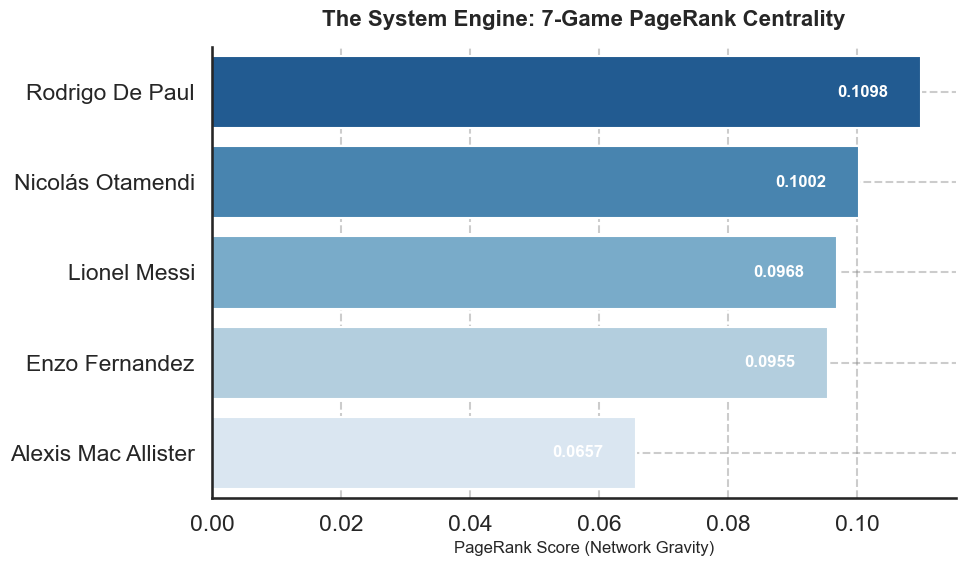

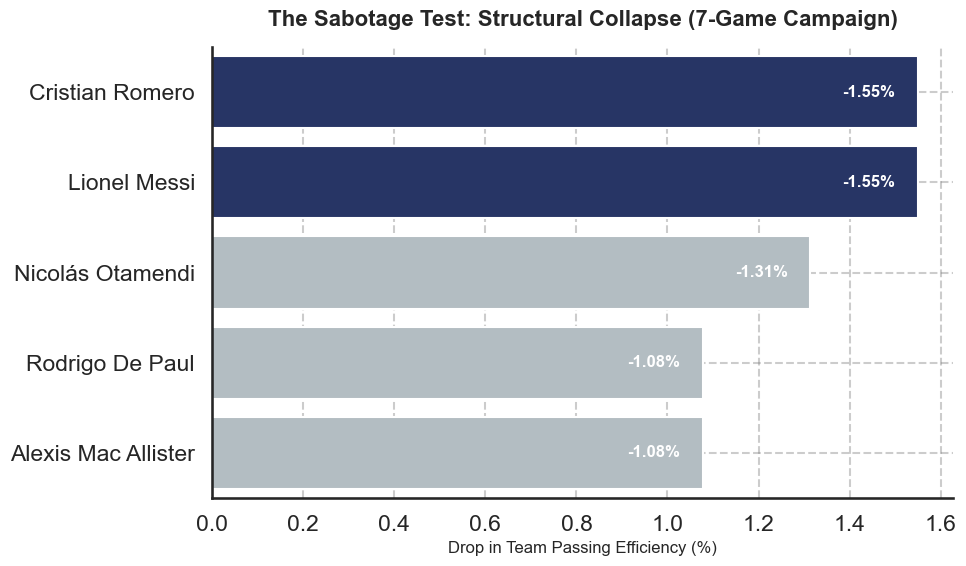

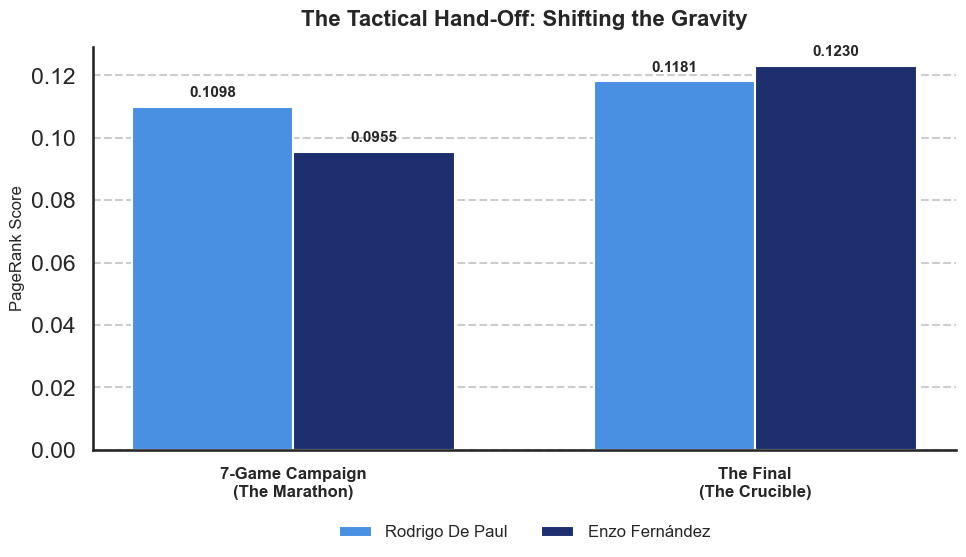

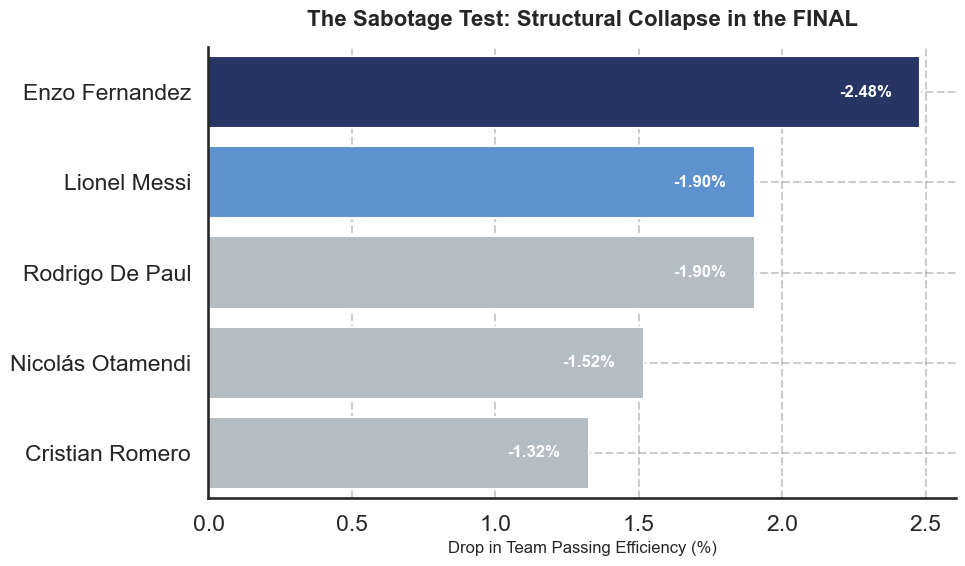

✅ All processing complete and all 4 graphs saved to local directory.


In [1]:
import requests
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def fetch_and_process_data():
    print("1. Fetching World Cup 2022 Match Data...")
    matches_url = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/matches/43/106.json"
    matches = requests.get(matches_url).json()

    arg_match_ids = []
    final_match_id = 3869151
    
    for match in matches:
        if match['home_team']['home_team_name'] == 'Argentina' or match['away_team']['away_team_name'] == 'Argentina':
            arg_match_ids.append(match['match_id'])

    # Initialize Graphs
    G_campaign = nx.DiGraph()
    G_final = nx.DiGraph()

    print("2. Processing Event Data for Passing Networks (This takes a few seconds)...")
    for match_id in arg_match_ids:
        events_url = f"https://raw.githubusercontent.com/statsbomb/open-data/master/data/events/{match_id}.json"
        events = requests.get(events_url).json()
        
        for event in events:
            if event.get('type', {}).get('name') == 'Pass' and event.get('team', {}).get('name') == 'Argentina':
                passer = event.get('player', {}).get('name', 'Unknown')
                recipient = event.get('pass', {}).get('recipient', {}).get('name')
                outcome = event.get('pass', {}).get('outcome', {}).get('name')
                
                # Only count successful passes
                if recipient and outcome is None: 
                    # Clean names for plotting readability
                    passer = passer.replace("Lionel Andrés Messi Cuccittini", "Lionel Messi")\
                                   .replace("Rodrigo Javier De Paul", "Rodrigo De Paul")\
                                   .replace("Enzo Jeremías Fernández", "Enzo Fernández")\
                                   .replace("Nicolás Hernán Otamendi", "Nicolás Otamendi")\
                                   .replace("Cristian Gabriel Romero", "Cristian Romero")
                    recipient = recipient.replace("Lionel Andrés Messi Cuccittini", "Lionel Messi")\
                                         .replace("Rodrigo Javier De Paul", "Rodrigo De Paul")\
                                         .replace("Enzo Jeremías Fernández", "Enzo Fernández")\
                                         .replace("Nicolás Hernán Otamendi", "Nicolás Otamendi")\
                                         .replace("Cristian Gabriel Romero", "Cristian Romero")
                    
                    # Add to Campaign Network
                    if G_campaign.has_edge(passer, recipient):
                        G_campaign[passer][recipient]['weight'] += 1
                    else:
                        G_campaign.add_edge(passer, recipient, weight=1)
                        
                    # Add to Final Network if it's the Final match
                    if match_id == final_match_id:
                        if G_final.has_edge(passer, recipient):
                            G_final[passer][recipient]['weight'] += 1
                        else:
                            G_final.add_edge(passer, recipient, weight=1)

    print("3. Calculating Network Metrics...")
    # PageRank
    pr_campaign = nx.pagerank(G_campaign, weight='weight', alpha=0.85)
    pr_final = nx.pagerank(G_final, weight='weight', alpha=0.85)

    # Sabotage Test (Global Efficiency Drop for Campaign)
    initial_efficiency_campaign = nx.global_efficiency(G_campaign.to_undirected())
    sabotage_campaign = {}
    
    for node in list(G_campaign.nodes()):
        G_temp = G_campaign.copy()
        G_temp.remove_node(node)
        if len(G_temp.nodes()) > 1:
            temp_efficiency = nx.global_efficiency(G_temp.to_undirected())
            drop_pct = ((initial_efficiency_campaign - temp_efficiency) / initial_efficiency_campaign) * 100
            sabotage_campaign[node] = drop_pct

    # Sabotage Test (Global Efficiency Drop for the FINAL only)
    initial_efficiency_final = nx.global_efficiency(G_final.to_undirected())
    sabotage_final = {}
    
    for node in list(G_final.nodes()):
        G_temp = G_final.copy()
        G_temp.remove_node(node)
        if len(G_temp.nodes()) > 1:
            temp_efficiency = nx.global_efficiency(G_temp.to_undirected())
            drop_pct = ((initial_efficiency_final - temp_efficiency) / initial_efficiency_final) * 100
            sabotage_final[node] = drop_pct

    return pr_campaign, pr_final, sabotage_campaign, sabotage_final


def plot_graphs(pr_campaign, pr_final, sabotage_campaign, sabotage_final):
    print("4. Generating and Saving Graphs...")
    
    # Base Aesthetic Settings
    sns.set_theme(style="white", context="talk")
    plt.rcParams['font.family'] = 'sans-serif'
    
    # ---------------------------------------------------------
    # GRAPH 1: The Gravity (PageRank Centrality - Campaign)
    # ---------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    
    # Sort and extract top 5
    top_pr = sorted(pr_campaign.items(), key=lambda x: x[1], reverse=True)[:5]
    players_g1 = [p[0] for p in top_pr]
    scores_g1 = [p[1] for p in top_pr]
    
    sns.barplot(x=scores_g1, y=players_g1, hue=players_g1, palette="Blues_r", dodge=False, ax=ax1, legend=False)
    ax1.set_title("The System Engine: 7-Game PageRank Centrality", fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel("PageRank Score (Network Gravity)", fontsize=12)
    ax1.set_ylabel("")
    
    # Visual styling: Add X/Y grids, remove background, remove top/right spines
    ax1.grid(True, axis='both', linestyle='--', alpha=0.4, color='gray')
    sns.despine(ax=ax1)
    
    for p in ax1.patches:
        ax1.annotate(f"{p.get_width():.4f}", 
                     (p.get_width() - 0.005, p.get_y() + p.get_height() / 2.), 
                     ha='right', va='center', color='white', fontweight='bold', fontsize=12)
        
    plt.tight_layout()
    # plt.savefig("graph1_gravity.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # GRAPH 2: The Two Poles (Sabotage Test - Campaign)
    # ---------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    
    top_sab_camp = sorted(sabotage_campaign.items(), key=lambda x: x[1], reverse=True)[:5]
    players_g2 = [p[0] for p in top_sab_camp]
    drops_g2 = [p[1] for p in top_sab_camp]
    
    # Highlight Romero and Messi in dark blue, others in grey
    colors_g2 = ['#1D2F6F' if p in ['Cristian Romero', 'Lionel Messi'] else '#B0BEC5' for p in players_g2]
    
    sns.barplot(x=drops_g2, y=players_g2, hue=players_g2, palette=colors_g2, dodge=False, ax=ax2, legend=False)
    ax2.set_title("The Sabotage Test: Structural Collapse (7-Game Campaign)", fontsize=16, fontweight='bold', pad=15)
    ax2.set_xlabel("Drop in Team Passing Efficiency (%)", fontsize=12)
    ax2.set_ylabel("")
    
    ax2.grid(True, axis='both', linestyle='--', alpha=0.4, color='gray')
    sns.despine(ax=ax2)
    
    for p in ax2.patches:
        ax2.annotate(f"-{p.get_width():.2f}%", 
                     (p.get_width() - 0.05, p.get_y() + p.get_height() / 2.), 
                     ha='right', va='center', color='white', fontweight='bold', fontsize=12)
        
    plt.tight_layout()
    # plt.savefig("graph2_sabotage_campaign.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # GRAPH 3: The Tactical Hand-Off (PageRank Compare)
    # ---------------------------------------------------------
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    
    labels = ['7-Game Campaign\n(The Marathon)', 'The Final\n(The Crucible)']
    
    # Safely extract scores
    dp_camp = pr_campaign.get('Rodrigo De Paul', 0)
    dp_final = pr_final.get('Rodrigo De Paul', 0)
    ef_camp = pr_campaign.get('Enzo Fernandez', pr_campaign.get('Enzo Fernández', 0))
    ef_final = pr_final.get('Enzo Fernandez', pr_final.get('Enzo Fernández', 0))
    
    de_paul = [dp_camp, dp_final]
    enzo = [ef_camp, ef_final]
    
    x = np.arange(len(labels))
    width = 0.35
    
    rects1 = ax3.bar(x - width/2, de_paul, width, label='Rodrigo De Paul', color='#4A90E2')
    rects2 = ax3.bar(x + width/2, enzo, width, label='Enzo Fernández', color='#1D2F6F')
    
    ax3.set_ylabel('PageRank Score', fontsize=12)
    ax3.set_title("The Tactical Hand-Off: Shifting the Gravity", fontsize=16, fontweight='bold', pad=15)
    ax3.set_xticks(x)
    ax3.set_xticklabels(labels, fontsize=12, fontweight='bold')
    
    ax3.grid(True, axis='y', linestyle='--', alpha=0.4, color='gray')
    sns.despine(ax=ax3)
    
    # Place Legend at the bottom
    ax3.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
    
    # Annotate bars
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax3.annotate(f'{height:.4f}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 5), 
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
        
    plt.tight_layout()
    # plt.savefig("graph3_handoff.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------
    # GRAPH 4: The Final Crucible (Sabotage Test - Final)
    # ---------------------------------------------------------
    fig4, ax4 = plt.subplots(figsize=(10, 6))
    
    top_sab_final = sorted(sabotage_final.items(), key=lambda x: x[1], reverse=True)[:5]
    players_g4 = [p[0] for p in top_sab_final]
    drops_g4 = [p[1] for p in top_sab_final]
    
    # Highlight Enzo in Dark Blue, Messi in Light Blue to emphasize the comparison
    colors_g4 = []
    for p in players_g4:
        if 'Enzo' in p:
            colors_g4.append('#1D2F6F')  # Dark Blue
        elif 'Messi' in p:
            colors_g4.append('#4A90E2')  # Light Blue
        else:
            colors_g4.append('#B0BEC5')  # Grey
            
    sns.barplot(x=drops_g4, y=players_g4, hue=players_g4, palette=colors_g4, dodge=False, ax=ax4, legend=False)
    ax4.set_title("The Sabotage Test: Structural Collapse in the FINAL", fontsize=16, fontweight='bold', pad=15)
    ax4.set_xlabel("Drop in Team Passing Efficiency (%)", fontsize=12)
    ax4.set_ylabel("")
    
    ax4.grid(True, axis='both', linestyle='--', alpha=0.4, color='gray')
    sns.despine(ax=ax4)
    
    for p in ax4.patches:
        ax4.annotate(f"-{p.get_width():.2f}%", 
                     (p.get_width() - 0.1, p.get_y() + p.get_height() / 2.), 
                     ha='right', va='center', color='white', fontweight='bold', fontsize=12)
        
    plt.tight_layout()
    # plt.savefig("graph4_final_sabotage.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    pr_camp, pr_fin, sab_camp, sab_fin = fetch_and_process_data()
    plot_graphs(pr_camp, pr_fin, sab_camp, sab_fin)
    print("✅ All processing complete and all 4 graphs saved to local directory.")